In [14]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Load data
air_df = pd.read_parquet("data/netherlands_air_quality_2013_2025.parquet")
pollutants_df = pd.read_parquet("data/pollutants.parquet")

In [9]:
air_df = air_df.merge(pollutants_df[["notation", "pk"]], left_on = "Pollutant", right_on = "pk", how="left")

In [10]:
air_df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog,notation,pk
0,NL/SPO-NL00641_00005_101,5,2013-01-01 00:00:00,2013-01-01 01:00:00,39.412000000000000000,ug.m-3,hour,1,1,2014-09-30 13:19:28,None,cf0579e6-a115-4778-8195-a50c79a5b5cc,Cd in PM2.5,5.0
1,NL/SPO-NL00641_00005_101,5,2013-01-01 01:00:00,2013-01-01 02:00:00,36.652000000000000000,ug.m-3,hour,1,1,2014-09-30 13:19:28,None,cf0579e6-a115-4778-8195-a50c79a5b5cc,Cd in PM2.5,5.0
2,NL/SPO-NL00641_00005_101,5,2013-01-01 02:00:00,2013-01-01 03:00:00,16.336000000000000000,ug.m-3,hour,1,1,2014-09-30 13:19:28,None,cf0579e6-a115-4778-8195-a50c79a5b5cc,Cd in PM2.5,5.0
3,NL/SPO-NL00641_00005_101,5,2013-01-01 03:00:00,2013-01-01 04:00:00,13.336000000000000000,ug.m-3,hour,1,1,2014-09-30 13:19:28,None,cf0579e6-a115-4778-8195-a50c79a5b5cc,Cd in PM2.5,5.0
4,NL/SPO-NL00641_00005_101,5,2013-01-01 04:00:00,2013-01-01 05:00:00,8.560000000000000000,ug.m-3,hour,1,1,2014-09-30 13:19:28,None,cf0579e6-a115-4778-8195-a50c79a5b5cc,Cd in PM2.5,5.0


In [19]:
# Ensure correct data types
air_df["Start"] = pd.to_datetime(air_df["Start"])
air_df["End"] = pd.to_datetime(air_df["End"])
air_df["Value"] = pd.to_numeric(air_df["Value"], errors='coerce')
air_df["Pollutant"] = pd.to_numeric(air_df["Pollutant"], errors='coerce')

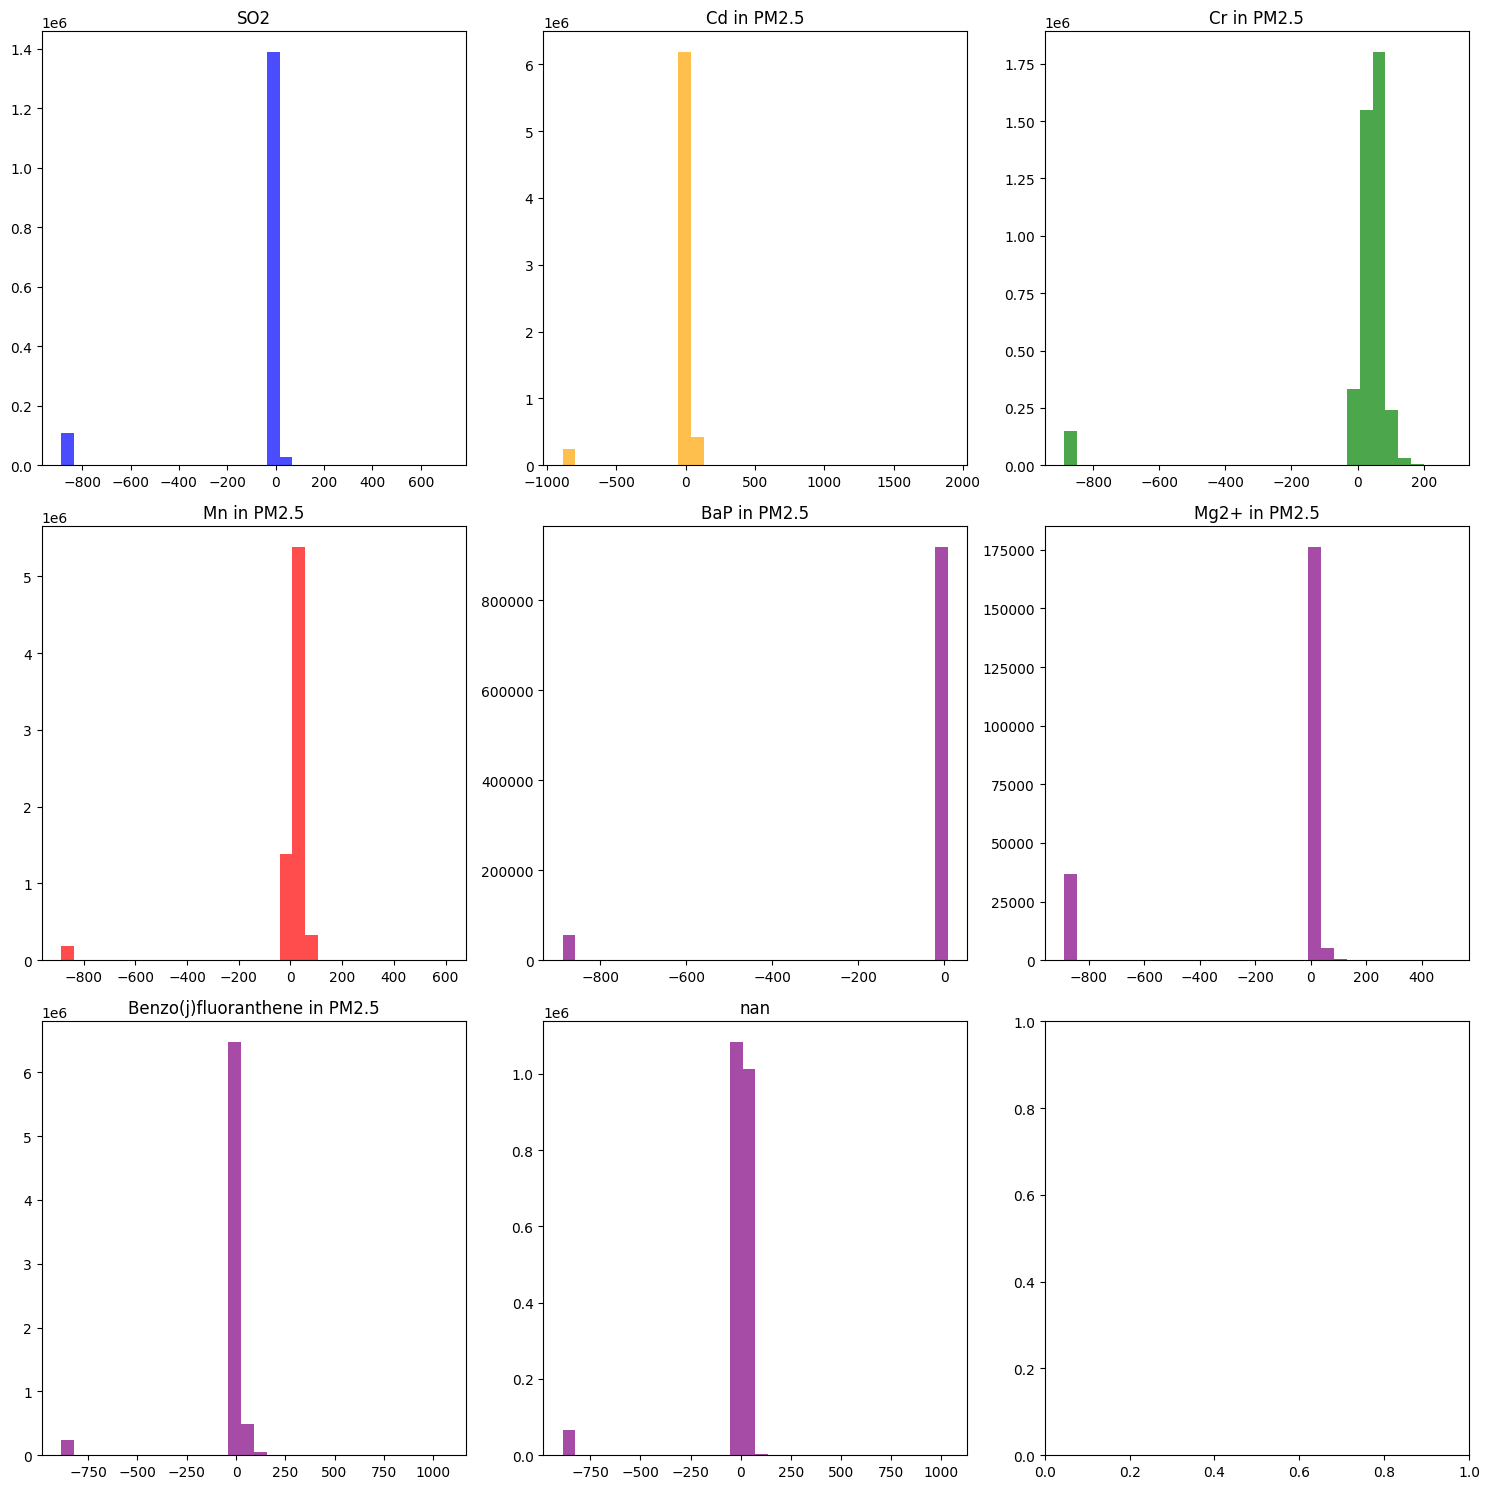

In [27]:
# Histogram per pollutant

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

axes[0,0].hist(air_df[air_df["Pollutant"] == 1]["Value"].dropna(), bins=30, color='blue', alpha=0.7)
axes[0,0].set_title(air_df[air_df["Pollutant"] == 1]["notation"].iloc[0])
axes[0,1].hist(air_df[air_df["Pollutant"] == 5]["Value"].dropna(), bins=30, color='orange', alpha=0.7)
axes[0,1].set_title(air_df[air_df["Pollutant"] == 5]["notation"].iloc[0])
axes[0,2].hist(air_df[air_df["Pollutant"] == 7]["Value"].dropna(), bins=30, color='green', alpha=0.7)
axes[0,2].set_title(air_df[air_df["Pollutant"] == 7]["notation"].iloc[0])
axes[1,0].hist(air_df[air_df["Pollutant"] == 8]["Value"].dropna(), bins=30, color='red', alpha=0.7)
axes[1,0].set_title(air_df[air_df["Pollutant"] == 8]["notation"].iloc[0])
axes[1,1].hist(air_df[air_df["Pollutant"] == 10]["Value"].dropna(), bins=30, color='purple', alpha=0.7)
axes[1,1].set_title(air_df[air_df["Pollutant"] == 10]["notation"].iloc[0])
axes[1,2].hist(air_df[air_df["Pollutant"] == 35]["Value"].dropna(), bins=30, color='purple', alpha=0.7)
axes[1,2].set_title(air_df[air_df["Pollutant"] == 35]["notation"].iloc[0])
axes[2,0].hist(air_df[air_df["Pollutant"] == 38]["Value"].dropna(), bins=30, color='purple', alpha=0.7)
axes[2,0].set_title(air_df[air_df["Pollutant"] == 38]["notation"].iloc[0])
axes[2,1].hist(air_df[air_df["Pollutant"] == 6001]["Value"].dropna(), bins=30, color='purple', alpha=0.7)
axes[2,1].set_title(air_df[air_df["Pollutant"] == 6001]["notation"].iloc[0])

plt.tight_layout()
plt.show()


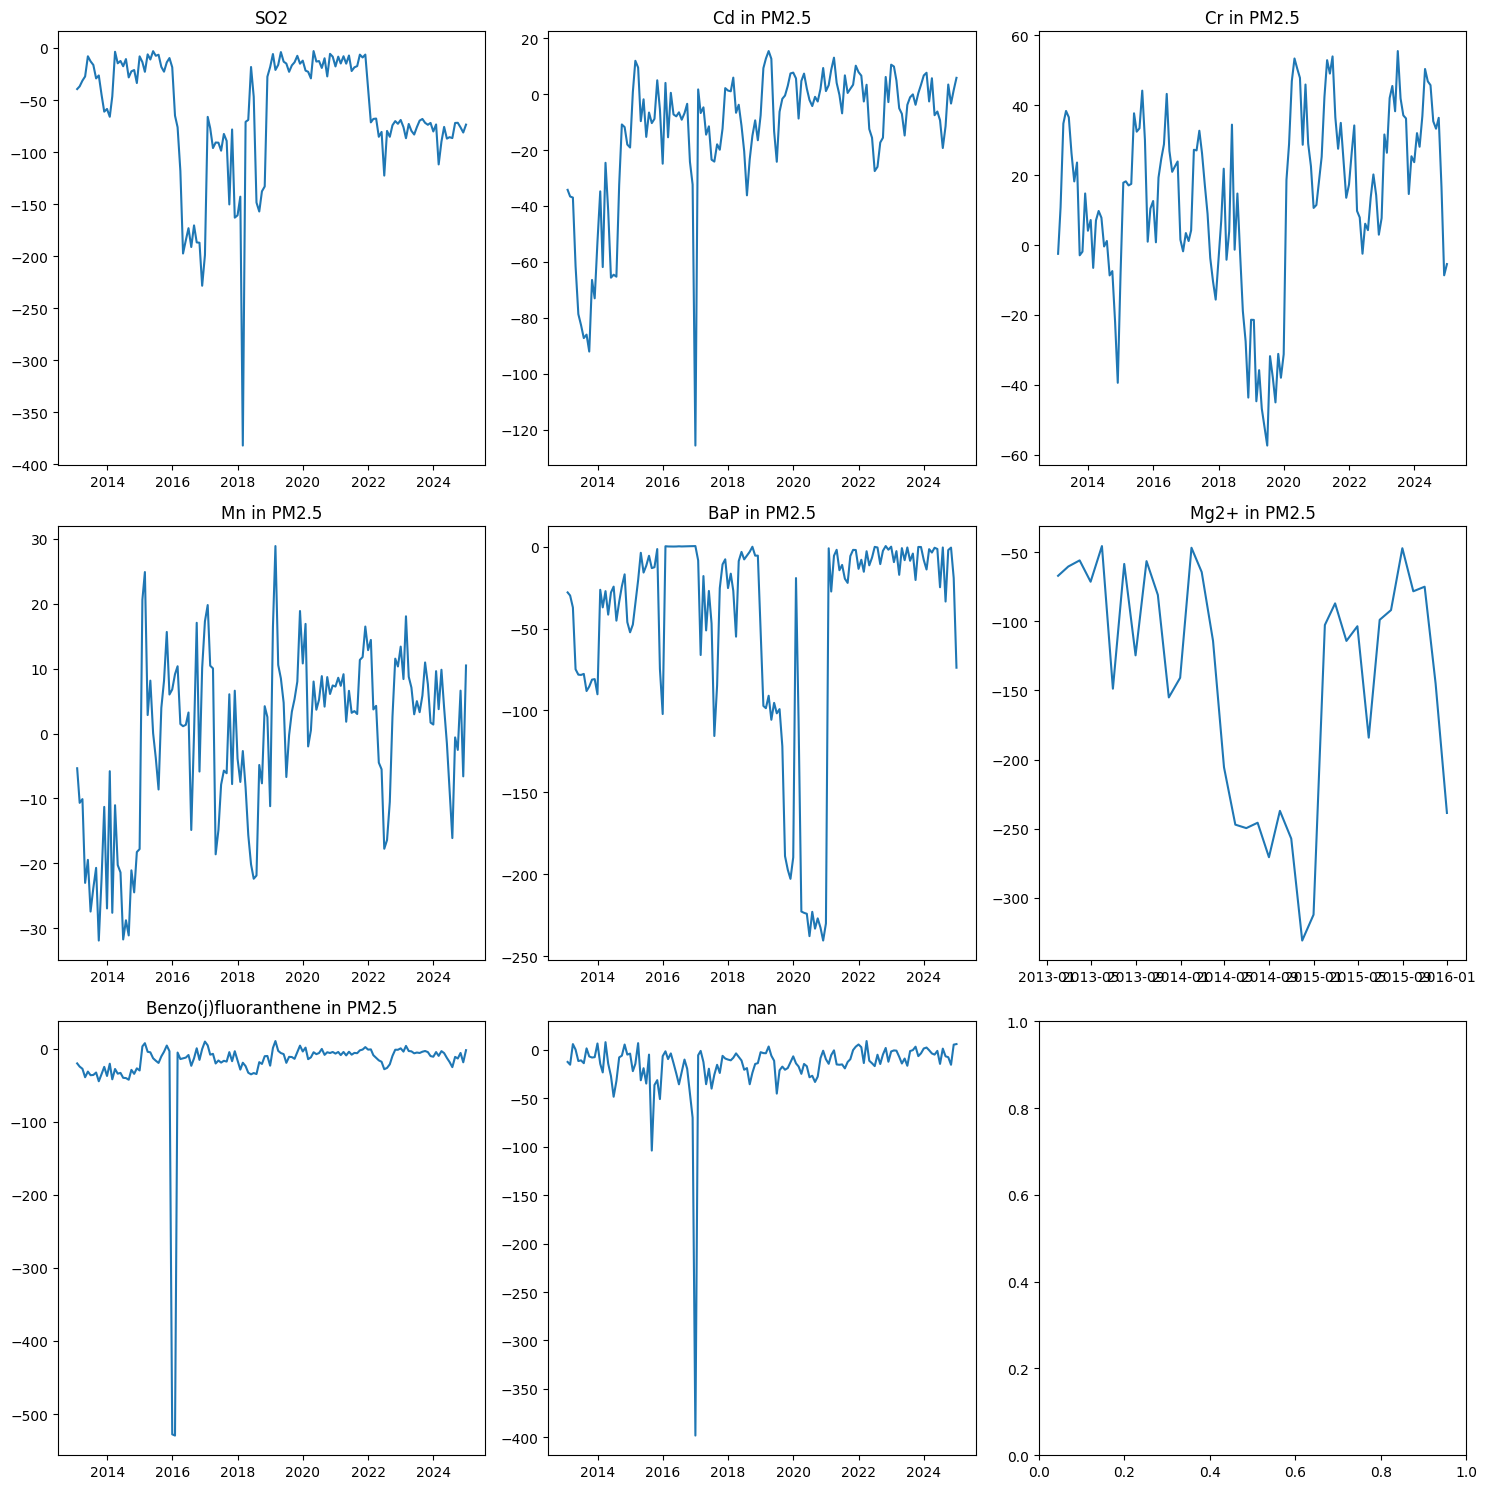

In [ ]:
pollutants = [1,5,7,8,10,35,38,6001]

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):

    df_p = air_df[air_df["Pollutant"] == pollutant].copy()

    # Convert time column
    df_p["Start"] = pd.to_datetime(df_p["Start"])

    # Monthly aggregation
    monthly = (
        df_p
        .set_index("Start")["Value"]
        .resample("ME")
        .mean()
    )

    axes[i].plot(monthly.index, monthly.values)
    
    # Title safely (avoid empty dataframe crash)
    if not df_p.empty:
        axes[i].set_title(df_p["notation"].iloc[0])
    else:
        axes[i].set_title(f"Pollutant {pollutant}")

plt.tight_layout()
plt.show()

In [34]:
# remove outliers
Q1 = air_df["Value"].quantile(0.25)
Q3 = air_df["Value"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
air_df_no_outliers = air_df[(air_df["Value"] >= lower_bound) & (air_df["Value"] <= upper_bound)]

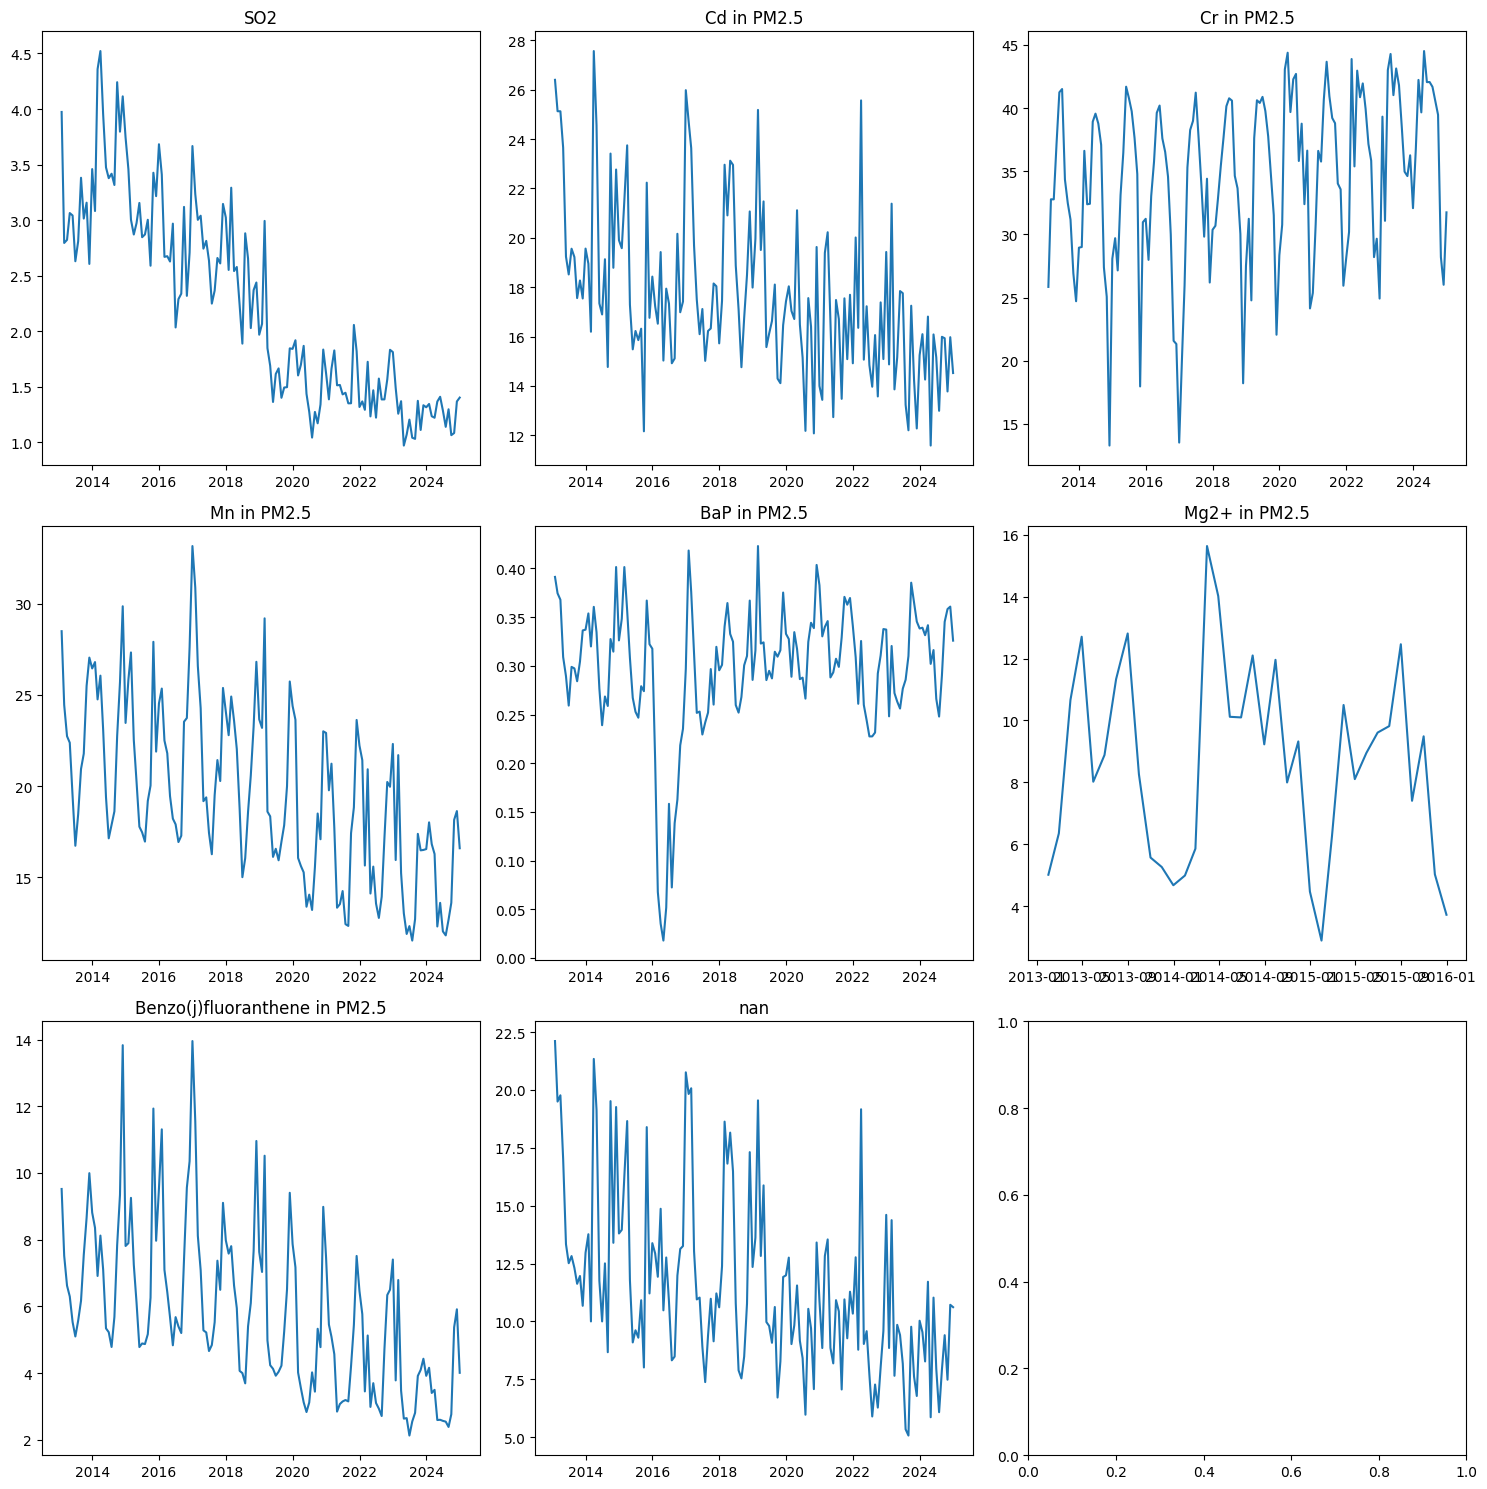

In [35]:
pollutants = [1,5,7,8,10,35,38,6001]

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):

    df_p = air_df_no_outliers[air_df_no_outliers["Pollutant"] == pollutant].copy()

    # Convert time column
    df_p["Start"] = pd.to_datetime(df_p["Start"])

    # Monthly aggregation
    monthly = (
        df_p
        .set_index("Start")["Value"]
        .resample("ME")
        .mean()
    )

    axes[i].plot(monthly.index, monthly.values)
    
    # Title safely (avoid empty dataframe crash)
    if not df_p.empty:
        axes[i].set_title(df_p["notation"].iloc[0])
    else:
        axes[i].set_title(f"Pollutant {pollutant}")

plt.tight_layout()
plt.show()

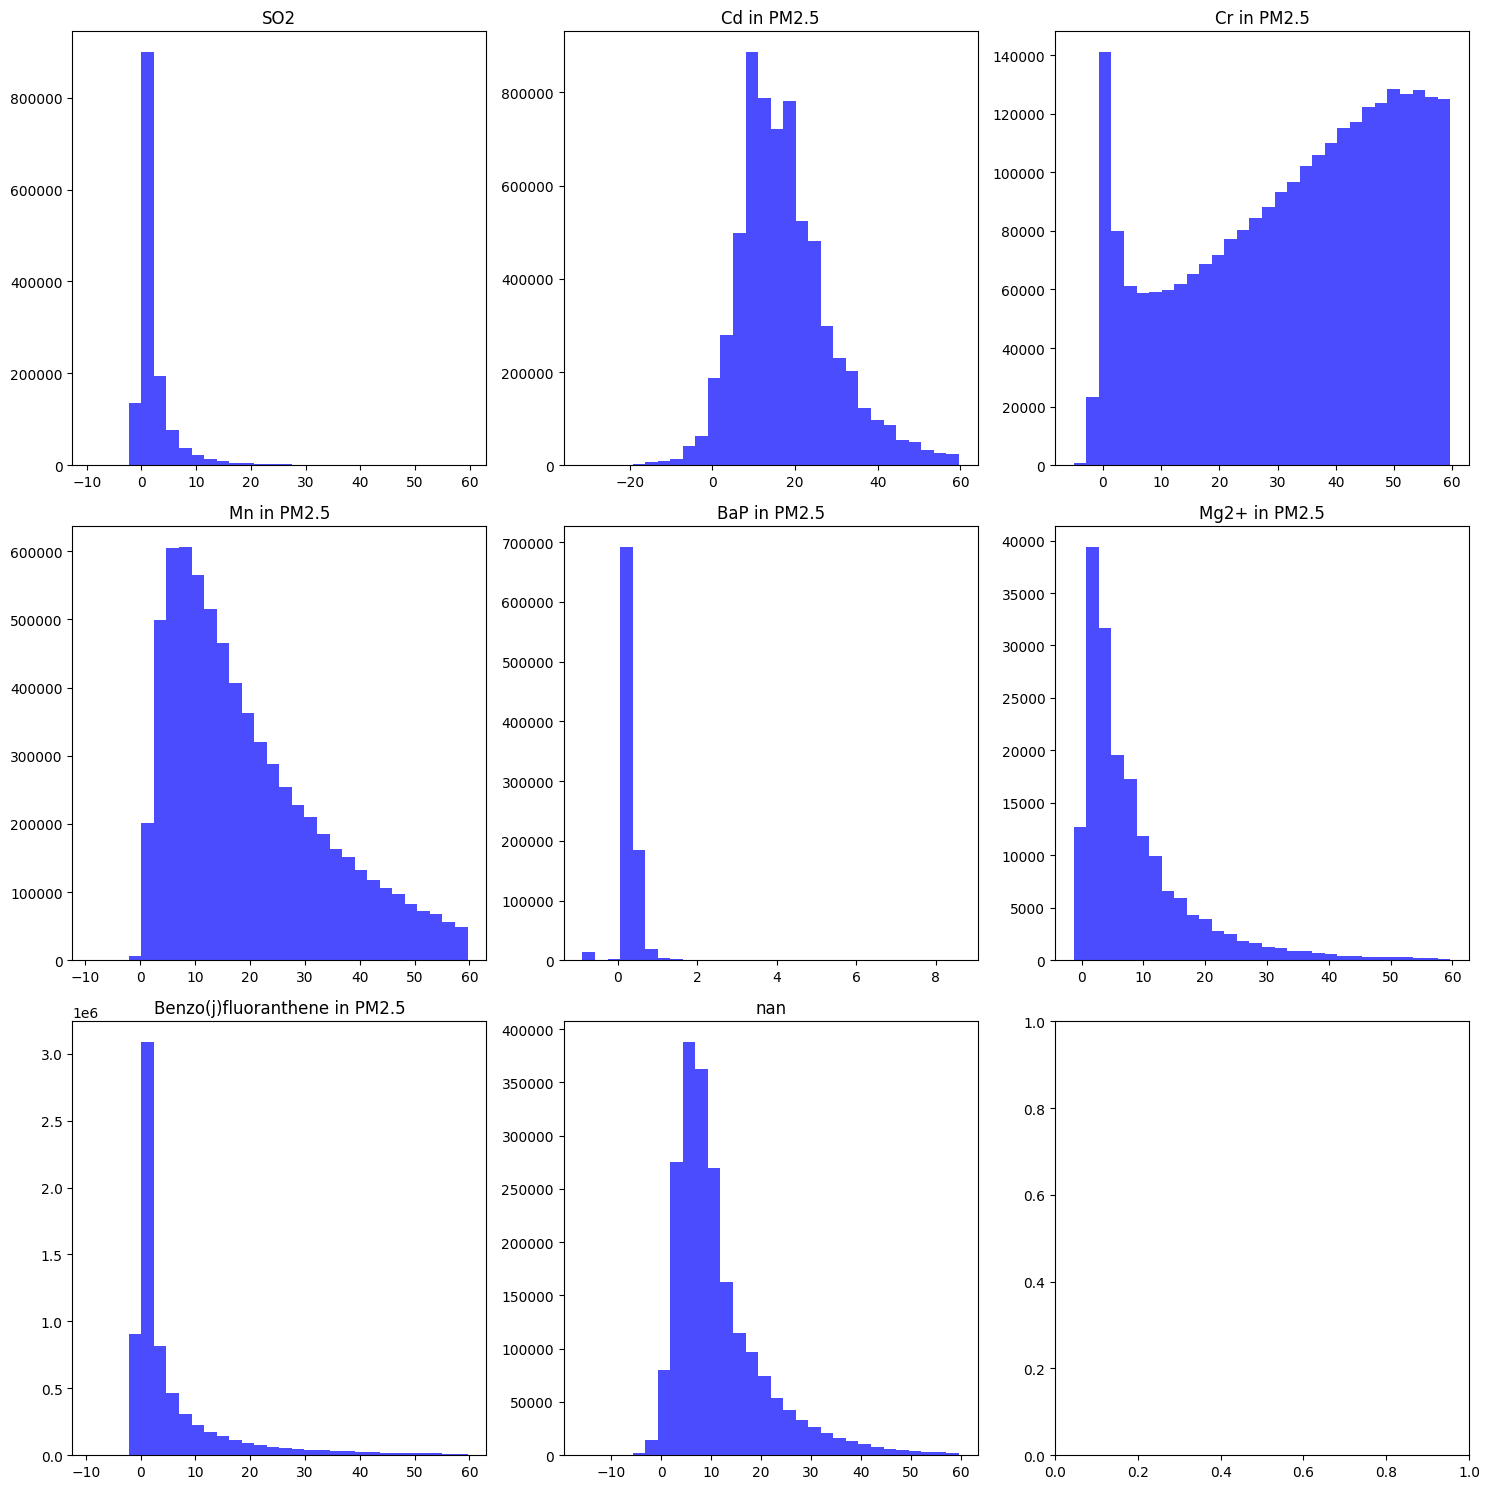

In [36]:
pollutants = [1,5,7,8,10,35,38,6001]

fig, axes = plt.subplots(3, 3, figsize=(15,15))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):

    axes[i].hist(air_df_no_outliers[air_df_no_outliers["Pollutant"] == pollutant]["Value"].dropna(), bins=30, color='blue', alpha=0.7)
    axes[i].set_title(air_df_no_outliers[air_df_no_outliers["Pollutant"] == pollutant]["notation"].iloc[0])

plt.tight_layout()
plt.show()